<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-7/7.5_decision_trees(ex).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn

In [14]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('/content/diabetes.csv',
                   names=col_names,
                   skiprows=1)

print(data.shape)
data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


In [16]:
feature_cols = ['pregnant', 'insulin', 'bmi',
                'age', 'glucose', 'bp', 'pedigree']

X = data[feature_cols]
y = data.label

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)

print(x_train.shape)
print(x_test.shape)

(614, 7)
(154, 7)


In [18]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(y_pred)

[1 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 0
 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 0
 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 1 0 0
 0 0 0 0 0 1]


In [19]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix :")
print(conf_mat)

accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy_score)
print("Accuracy in Percentage :", int(accuracy_score * 100), "%")

Confusion Matrix :
[[72 27]
 [21 34]]
Accuracy Score : 0.6883116883116883
Accuracy in Percentage : 68 %


<Axes: xlabel='Predicted', ylabel='Actual'>

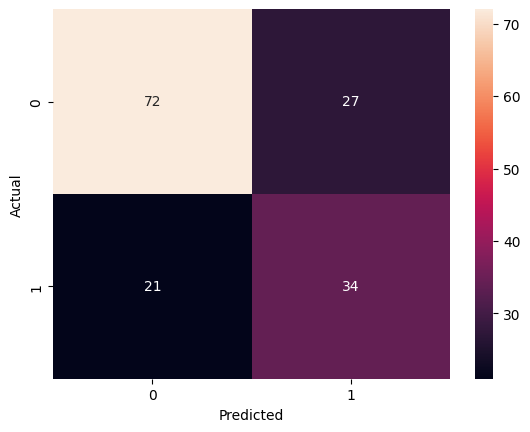

In [20]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)